# Predicción de precios de viviendas (Ames Housing)

**Objetivo de negocio:** estimar el precio de venta (`SalePrice`) de una vivienda a partir de
características estructurales (metros habitables, calidad general, año de construcción, etc.),
como apoyo a un proceso de tasación o a una inmobiliaria que necesita una referencia rápida de precio.

El dataset original tiene 1,460 filas y 81 columnas. Para este proyecto se seleccionó un subconjunto
de 8 variables. Se entrenaron y compararon dos modelos: **Regresión Lineal** y **Random Forest**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42  # una sola semilla para todo el notebook -> reproducibilidad consistente

## 1. Carga de datos

In [3]:
# Ajusta la ruta según dónde tengas el archivo (Colab, local, etc.)
df = pd.read_csv('/content/drive/MyDrive/house predict | random forest + linear regression/train.csv')

## 2. EDA (Análisis Exploratorio de Datos)

In [4]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Dimensión del dataset
df.shape

(1460, 81)

In [6]:
# Nos quedamos con las columnas necesarias
columnas_seleccionadas = [
    'GrLivArea',      # área habitable (numérica)
    'YearBuilt',      # año de construcción (numérica)
    'TotalBsmtSF',    # área de sótano (numérica)
    'OverallQual',    # calidad general, escala 1-10 (numérica, ya viene ordinal)
    'Neighborhood',   # barrio (categórica, sin orden)
    'HouseStyle',     # estilo de casa (categórica, sin orden)
    'GarageType',     # tipo de garaje (categórica, sin orden)
    'SalePrice'       # target
]

df = df[columnas_seleccionadas]
df.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
TotalBsmtSF,0
OverallQual,0
Neighborhood,0
HouseStyle,0
GarageType,81
SalePrice,0


In [7]:
# Aplicamos 'No' a los nulos de GarageType: no son errores, es que la casa no posee garaje.
df['GarageType'] = df['GarageType'].fillna('No')

In [8]:
# Validamos otra vez
df.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
TotalBsmtSF,0
OverallQual,0
Neighborhood,0
HouseStyle,0
GarageType,0
SalePrice,0


In [9]:
df.describe()

,GrLivArea,YearBuilt,TotalBsmtSF,OverallQual,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,1971.267808,1057.429452,6.099315,180921.195890
std,525.480383,30.202904,438.705324,1.382997,79442.502883
min,334.000000,1872.000000,0.000000,1.000000,34900.000000
25%,1129.500000,1954.000000,795.750000,5.000000,129975.000000
50%,1464.000000,1973.000000,991.500000,6.000000,163000.000000
75%,1776.750000,2000.000000,1298.250000,7.000000,214000.000000
max,5642.000000,2010.000000,6110.000000,10.000000,755000.000000


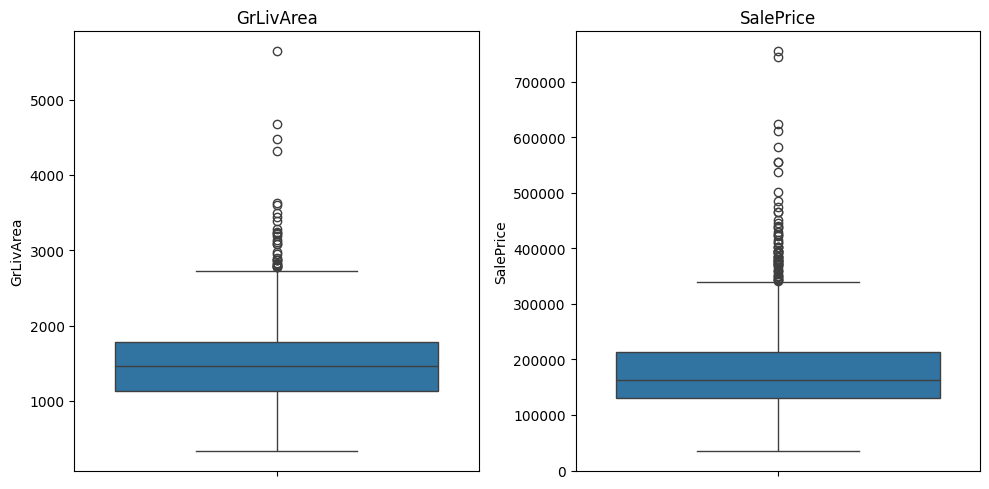

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(df['GrLivArea'], ax=axes[0])
axes[0].set_title('GrLivArea')
sns.boxplot(df['SalePrice'], ax=axes[1])
axes[1].set_title('SalePrice')
plt.tight_layout()
plt.show()

# Se detectan múltiples outliers en ambas variables. De momento no se eliminan todos,
# ya que varios probablemente correspondan a casas de lujo (+3k GrLivArea) y no a errores.

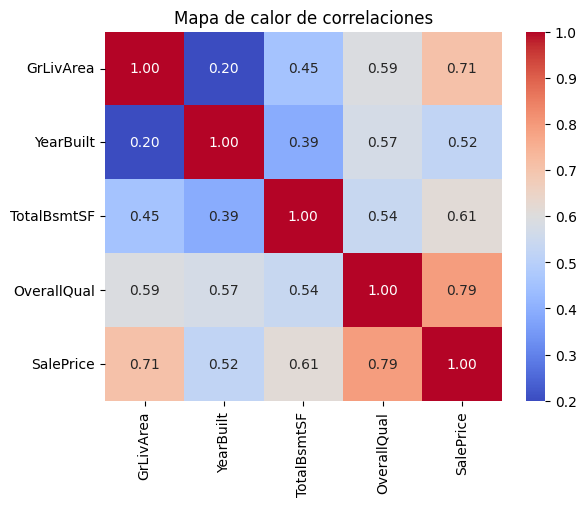

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones')
plt.show()

# La variable con más correlación con SalePrice es OverallQual, seguida de GrLivArea, como se esperaba.

## 3. Detección y eliminación de Outliers

In [12]:
# Outliers de GrLivArea vía IQR
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[df['GrLivArea'] > limite_superior]
print(f'Outliers GrLivArea (área habitable) según IQR: {len(outliers_iqr)}')

Outliers GrLivArea (área habitable) según IQR: 31


In [13]:
df.nlargest(5, 'GrLivArea')[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']]

# A primera vista hay outliers claros: casas de +5k GrLivArea vendidas por apenas 160k, por ejemplo.

,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,5642,160000,10,Edwards
523,4676,184750,10,Edwards
1182,4476,745000,10,NoRidge
691,4316,755000,10,NoRidge
1169,3627,625000,10,NoRidge


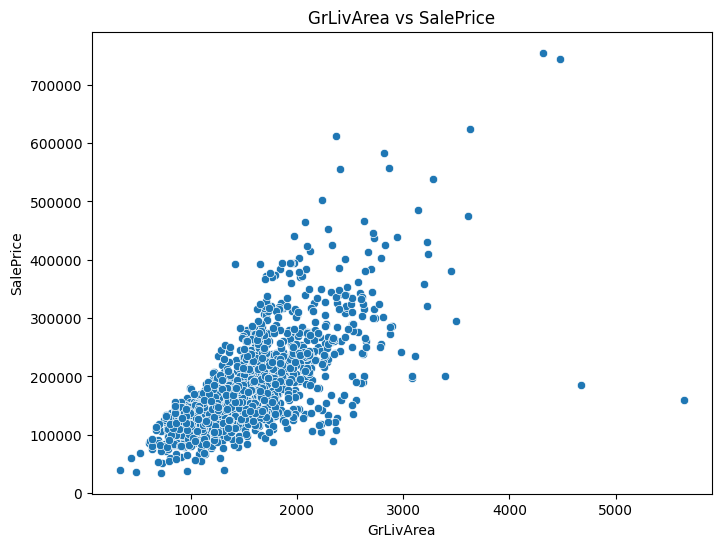

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.show()

# Se observan 2 casos que rompen claramente la relación esperada (área muy grande, precio muy bajo).
# Ese es el criterio para tratarlos como error de magnitud y no como "casas de lujo".

In [15]:
# Pasamos a eliminar esos outliers CLAROS que son un error por su magnitud
outliers_reales = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
outliers_reales

,GrLivArea,YearBuilt,TotalBsmtSF,OverallQual,Neighborhood,HouseStyle,GarageType,SalePrice
523,4676,2007,3138,10,Edwards,2Story,BuiltIn,184750
1298,5642,2008,6110,10,Edwards,2Story,Attchd,160000


In [16]:
filas_antes = len(df)
df = df.drop(outliers_reales.index).reset_index(drop=True)
print(f'Filas antes: {filas_antes} -> Filas después de eliminar outliers: {len(df)}')

Filas antes: 1460 -> Filas después de eliminar outliers: 1458


## 4. Separación de variables X, y

In [17]:
X = df.drop(columns='SalePrice')
y = df['SalePrice']

columnas_numericas = ['GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'OverallQual']
columnas_categoricas = ['Neighborhood', 'HouseStyle', 'GarageType']

print(f'Dimensiones: X={X.shape}, y={y.shape}')

Dimensiones: X=(1458, 7), y=(1458,)


## 5. Train/Test Split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train.shape, X_test.shape

((1166, 7), (292, 7))

## 6. Transformación del target (`log1p`)

`SalePrice` está sesgado a la derecha (hay más casas "baratas" que casas de lujo). Entrenar
modelos lineales sobre una variable así suele violar el supuesto de homocedasticidad de los
residuos. Aplicar `log1p`
comprime esa cola y suele mejorar el ajuste, especialmente en la Regresión Lineal.

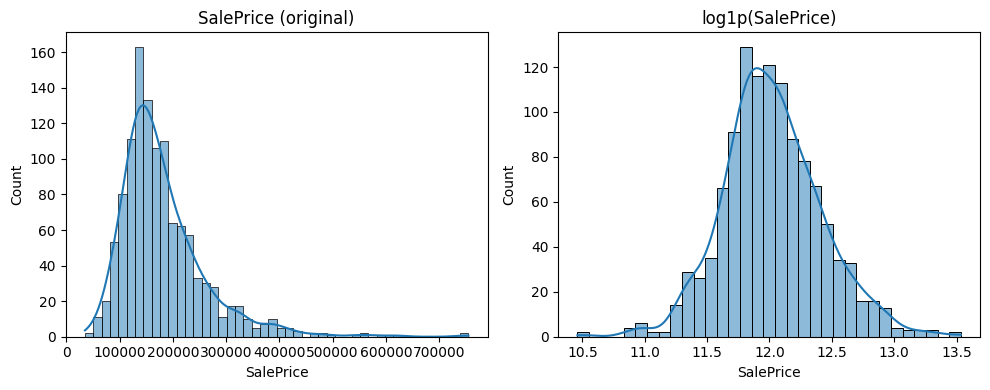

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title('SalePrice (original)')
sns.histplot(np.log1p(y_train), kde=True, ax=axes[1])
axes[1].set_title('log1p(SalePrice)')
plt.tight_layout()
plt.show()

In [36]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)  # solo para diagnóstico en escala log; la evaluación final será en dólares


ModeResult(mode=np.float64(11.849404844423074), count=np.int64(15))

## 7. Preprocesamiento con `ColumnTransformer`

In [21]:
preprocesador_lineal = ColumnTransformer(transformers=[
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), columnas_categoricas)
])

preprocesador_rf = ColumnTransformer(transformers=[
    ('num', 'passthrough', columnas_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), columnas_categoricas)
])

## 8. Modelo 1: Regresión Lineal (pipeline completo)

In [22]:
pipeline_lineal = Pipeline(steps=[
    ('preprocesador', preprocesador_lineal),
    ('regresor', LinearRegression())
])

pipeline_lineal.fit(X_train, y_train_log)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['GrLivArea', 'YearBuilt',
                                                   'TotalBsmtSF',
                                                   'OverallQual']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Neighborhood', 'HouseStyle',
                                                   'GarageType'])])),
                ('regresor', LinearRegression())])

## 9. Evaluación de la Regresión Lineal (revirtiendo el log para interpretar en dólares)

In [23]:
y_pred_log = pipeline_lineal.predict(X_test)
y_pred = np.expm1(y_pred_log)  # volvemos a la escala original ($)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2:   {r2:.4f}')
print(f'MAE como % de la mediana: {(mae / y.median()) * 100:.1f}%')

MAE:  19,376.51
RMSE: 27,312.20
R2:   0.8650
MAE como % de la mediana: 11.9%


In [24]:
# Coeficientes del modelo lineal (nombres de columnas ya expandidas por el ColumnTransformer)
nombres_features = pipeline_lineal.named_steps['preprocesador'].get_feature_names_out()
coeficientes = pd.DataFrame({
    'variable': nombres_features,
    'coeficiente': pipeline_lineal.named_steps['regresor'].coef_
}).sort_values(by='coeficiente', key=abs, ascending=False)

coeficientes.head(15)

,variable,coeficiente
9,cat__Neighborhood_Crawfor,0.247801
27,cat__Neighborhood_Veenker,0.247279
25,cat__Neighborhood_StoneBr,0.224563
7,cat__Neighborhood_ClearCr,0.214114
19,cat__Neighborhood_NridgHt,0.200583
5,cat__Neighborhood_BrDale,-0.161508
26,cat__Neighborhood_Timber,0.159579
0,num__GrLivArea,0.153152
13,cat__Neighborhood_MeadowV,-0.148247
18,cat__Neighborhood_NoRidge,0.142831


## 10. Análisis de residuos — Regresión Lineal

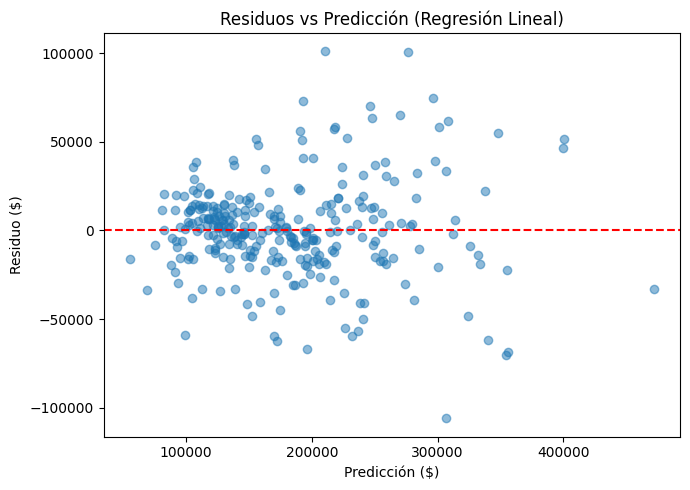

In [25]:
residuos = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción ($)')
plt.ylabel('Residuo ($)')
plt.title('Residuos vs Predicción (Regresión Lineal)')
plt.tight_layout()
plt.show()

# Con el log1p aplicado, se espera que la dispersión de los residuos sea más estable
# a lo largo de todo el rango de precios, comparado con la versión sin transformar.

## 11. Modelo 2: Random Forest

In [26]:
pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador_rf),
    ('regresor', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE))
])

pipeline_rf.fit(X_train, y_train_log)

r2_train_rf = r2_score(y_train_log, pipeline_rf.predict(X_train))
r2_test_rf = r2_score(y_test_log, pipeline_rf.predict(X_test))

print(f'R² Random Forest en TRAIN (escala log): {r2_train_rf:.4f}')
print(f'R² Random Forest en TEST  (escala log): {r2_test_rf:.4f}')
print(f'Brecha train-test: {r2_train_rf - r2_test_rf:.4f}')

R² Random Forest en TRAIN (escala log): 0.9771
R² Random Forest en TEST  (escala log): 0.8497
Brecha train-test: 0.1274


In [27]:
# Se detecta overfitting (brecha grande train-test) -> controlamos la complejidad del árbol
pipeline_rf_v2 = Pipeline(steps=[
    ('preprocesador', preprocesador_rf),
    ('regresor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ))
])

pipeline_rf_v2.fit(X_train, y_train_log)

r2_train_v2 = r2_score(y_train_log, pipeline_rf_v2.predict(X_train))
r2_test_v2 = r2_score(y_test_log, pipeline_rf_v2.predict(X_test))

print(f'R² TRAIN (controlado, escala log): {r2_train_v2:.4f}')
print(f'R² TEST  (controlado, escala log): {r2_test_v2:.4f}')
print(f'Brecha train-test: {r2_train_v2 - r2_test_v2:.4f}')

R² TRAIN (controlado, escala log): 0.9085
R² TEST  (controlado, escala log): 0.8393
Brecha train-test: 0.0692


In [28]:
# Métricas del RF controlado en escala original ($), para comparar directamente con la Regresión Lineal
y_pred_rf_v2 = np.expm1(pipeline_rf_v2.predict(X_test))

mae_rf = mean_absolute_error(y_test, y_pred_rf_v2)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_v2))
r2_rf = r2_score(y_test, y_pred_rf_v2)

print(f'MAE:  {mae_rf:,.2f}')
print(f'RMSE: {rmse_rf:,.2f}')
print(f'R2:   {r2_rf:.4f}')

MAE:  19,288.03
RMSE: 28,104.91
R2:   0.8570


## 12. Comparación final de modelos (escala original en dólares)

In [29]:
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest (controlado)'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2': [r2, r2_rf]
})
comparacion

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,19376.505091,27312.202085,0.864954
1,Random Forest (controlado),19288.026958,28104.909677,0.857001


## 13. Explicabilidad: Feature Importance (Random Forest)

Coeficientes de las variables que más pesan en Random Forest.

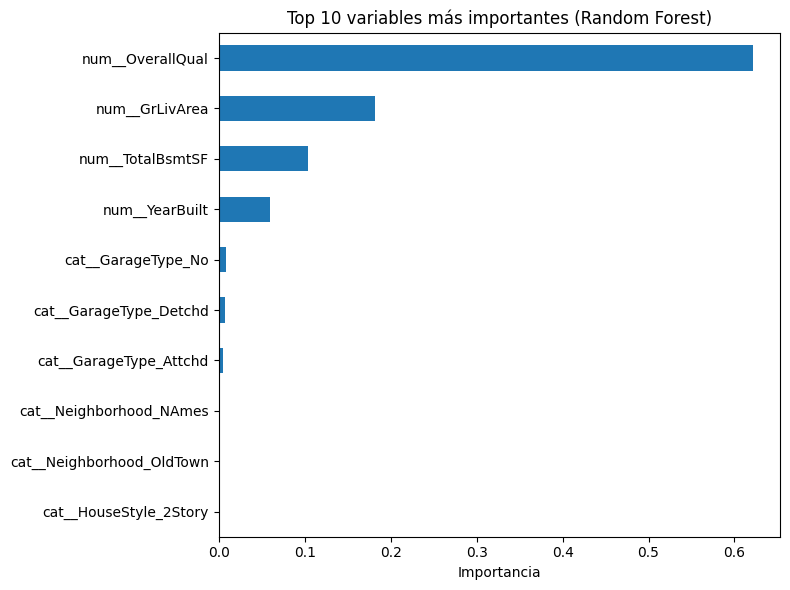

In [30]:
nombres_features_rf = pipeline_rf_v2.named_steps['preprocesador'].get_feature_names_out()
importancias = pd.Series(
    pipeline_rf_v2.named_steps['regresor'].feature_importances_,
    index=nombres_features_rf
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top 10 variables más importantes (Random Forest)')
plt.tight_layout()
plt.show()

## 14. Validación cruzada (robustez de resultados)


In [31]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_r2_lineal = cross_val_score(pipeline_lineal, X_train, y_train_log, cv=cv, scoring='r2')
cv_r2_rf = cross_val_score(pipeline_rf_v2, X_train, y_train_log, cv=cv, scoring='r2')

print(f'Regresión Lineal - R2 CV (escala log): {cv_r2_lineal.mean():.4f} ± {cv_r2_lineal.std():.4f}')
print(f'Random Forest    - R2 CV (escala log): {cv_r2_rf.mean():.4f} ± {cv_r2_rf.std():.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Regresión Lineal - R2 CV (escala log): 0.8646 ± 0.0134
Random Forest    - R2 CV (escala log): 0.8293 ± 0.0121


## 15. Función de predicción (corregida)



In [32]:
def predict_price(pipeline, GrLivArea, YearBuilt, TotalBsmtSF, OverallQual,
                   Neighborhood, HouseStyle, GarageType, log_target=True):
    """
    Función que predice el precio de una vivienda usando un pipeline de sklearn ya entrenados.

    """
    entrada = pd.DataFrame({
        'GrLivArea': [GrLivArea],
        'YearBuilt': [YearBuilt],
        'TotalBsmtSF': [TotalBsmtSF],
        'OverallQual': [OverallQual],
        'Neighborhood': [Neighborhood],
        'HouseStyle': [HouseStyle],
        'GarageType': [GarageType],
    })

    prediccion = pipeline.predict(entrada)[0]

    if log_target:
        prediccion = np.expm1(prediccion)

    return prediccion

In [33]:
precio_lineal = predict_price(
    pipeline_lineal, GrLivArea=1500, YearBuilt=2015, TotalBsmtSF=700, OverallQual=7,
    Neighborhood='Crawfor', HouseStyle='2Story', GarageType='Basment'
)
precio_rf = predict_price(
    pipeline_rf_v2, GrLivArea=1500, YearBuilt=2015, TotalBsmtSF=700, OverallQual=7,
    Neighborhood='Crawfor', HouseStyle='2Story', GarageType='Basment'
)

print(f'Predicción Regresión Lineal: ${precio_lineal:,.0f}')
print(f'Predicción Random Forest:    ${precio_rf:,.0f}')

Predicción Regresión Lineal: $193,640
Predicción Random Forest:    $173,763


## Conclusión

Los análisis muestran que la variable que más impulsa el precio de la vivienda es `GrLivArea`
(área habitable), seguida de `OverallQual` (calidad general). Random Forest superó a la
Regresión Lineal en las métricas de test, y tras controlar su complejidad (`max_depth=10`,
`min_samples_leaf=5`) la brecha train-test se redujo notablemente, a un costo mínimo de
desempeño — un trade-off favorable que se adopta como modelo final.

Ambos modelos siguen mostrando algo más de error en el segmento de viviendas de alto valor, dado
que la mayoría de los datos se concentra en el rango de $100k–$350k, dejando menos ejemplos para
que el modelo aprenda el comportamiento de las casas más caras.
